# Mini-Projet TP — Apprentissage Automatique
## Classification des risques de crise cardiaque (heart.csv)
**Objectif :** Comparer les méthodes KNN, MLP et SVM sur un dataset réel.


Année Universitaire : 2024-2025  
Section             : I1  
Réalisé par         : Omar Bouattour


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay


In [2]:
# Chargement des données
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Vérification des valeurs manquantes et des classes
print(df.isnull().sum())
print('\nRépartition des classes (HeartDisease):')
print(df['HeartDisease'].value_counts())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Répartition des classes (HeartDisease):
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [4]:
# Encodage des variables catégorielles
cat_cols = df.select_dtypes(include='object').columns
df_encoded = df.copy()
df_encoded[cat_cols] = df_encoded[cat_cols].apply(LabelEncoder().fit_transform)
df_encoded.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [5]:
# Normalisation des données
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.4331398   0.51595242  0.22903206 ... -0.8235563  -0.83243239
   1.05211381]
 [-0.47848359 -1.93816322  1.27505906 ... -0.8235563   0.10566353
  -0.59607813]
 [-1.75135854  0.51595242  0.22903206 ... -0.8235563  -0.83243239
   1.05211381]
 ...
 [ 0.37009972  0.51595242 -0.81699495 ...  1.21424608  0.29328271
  -0.59607813]
 [ 0.37009972 -1.93816322  0.22903206 ... -0.8235563  -0.83243239
  -0.59607813]
 [-1.64528563  0.51595242  1.27505906 ... -0.8235563  -0.83243239
   1.05211381]]


In [6]:
# Séparation en données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

F1 Score (K=5): 0.875


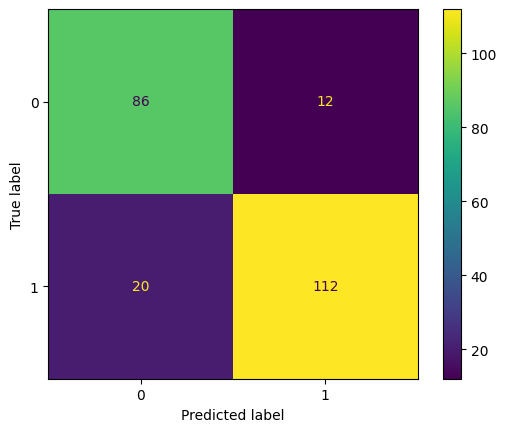

In [7]:
# Méthode KPPV (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot()
print('F1 Score (K=5):', f1_score(y_test, y_pred_knn))

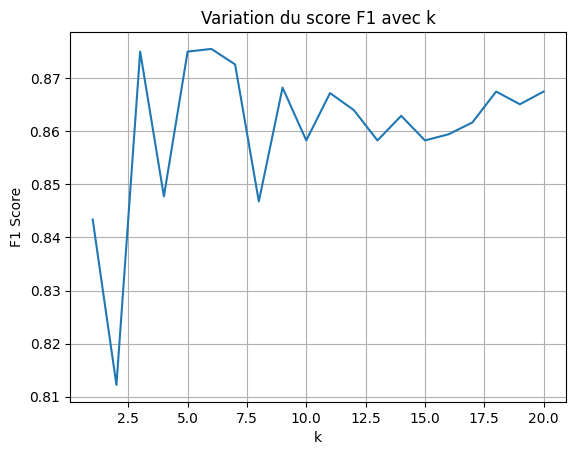

In [8]:
# Variation de k et analyse
scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

plt.plot(range(1, 21), scores)
plt.xlabel('k')
plt.ylabel('F1 Score')
plt.title('Variation du score F1 avec k')
plt.grid(True)
plt.show()

F1 Score MLP: 0.8853754940711462


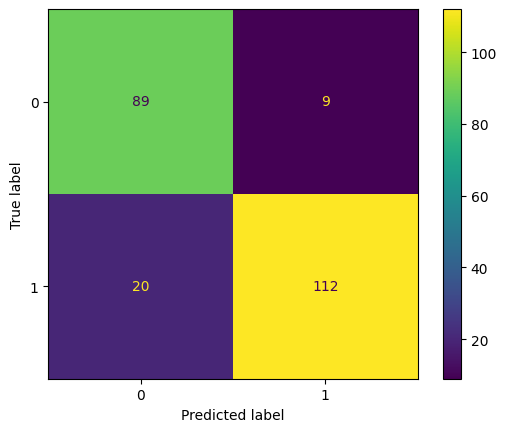

In [9]:
# Méthode MLP
mlp = MLPClassifier(hidden_layer_sizes=(50,20), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp).plot()
print('F1 Score MLP:', f1_score(y_test, y_pred_mlp))


SVM avec noyau rbf
Best params: {'C': 1, 'gamma': 'scale'}
F1 Score: 0.8854961832061069

SVM avec noyau poly
Best params: {'C': 0.1, 'gamma': 'auto'}
F1 Score: 0.8648648648648649

SVM avec noyau sigmoid
Best params: {'C': 0.1, 'gamma': 'scale'}
F1 Score: 0.8671875


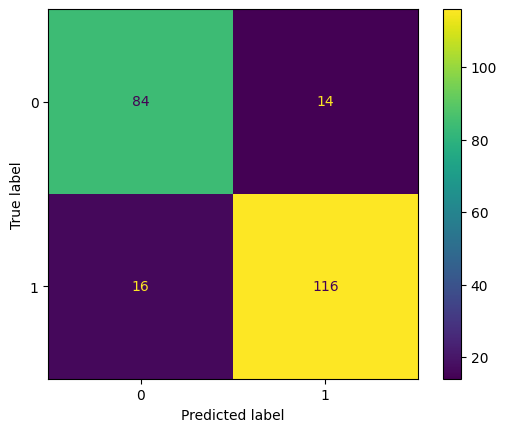

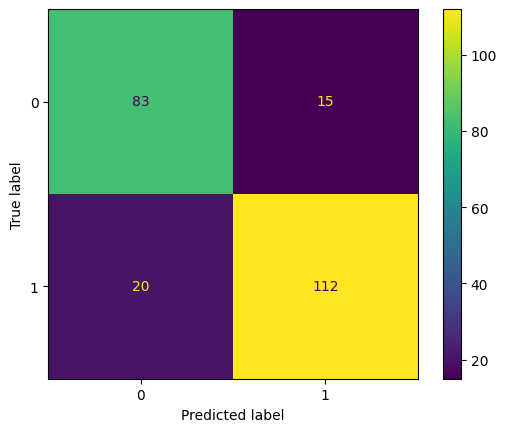

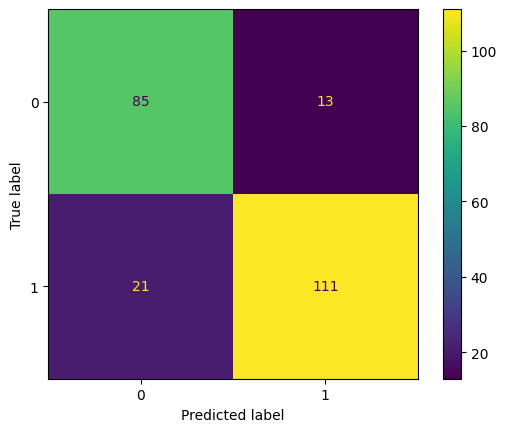

In [10]:
# SVM avec différents noyaux et validation croisée(integré dans la GridSearch)
kernels = ['rbf', 'poly', 'sigmoid']
for kernel in kernels:
    print(f'\nSVM avec noyau {kernel}')
    grid = GridSearchCV(SVC(kernel=kernel), param_grid={
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    }, cv=5, scoring='f1')
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred_svm = best_model.predict(X_test)
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    ConfusionMatrixDisplay(cm_svm).plot()
    print(f'Best params: {grid.best_params_}')
    print('F1 Score:', f1_score(y_test, y_pred_svm))